In [25]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
from pymongo import MongoClient
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

## Reading the data

In [4]:
def wrangle(collection, resample_freq="1h"):

    # Fetch data 
    results = collection.find(
        {}, 
        projection={"datetimeLocal": 1, "value": 1, "_id": 0}
    )
    
    df = pd.DataFrame(list(results))
    
    #rename columns
    df = df.rename(columns={"datetimeLocal": "timestamp", "value": "pm25"})
    #convert datatype
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    
    # Set index and handle timezone
    df.set_index("timestamp", inplace=True)
    
    df.index = df.index.tz_convert("Africa/Casablanca")

    # Remove outliers 
    df = df[df["pm25"] < 500]

    # Resample to 1-hour window, forward-fill missing values
    y = df["pm25"].resample(resample_freq).mean().interpolate()


    return y

In [5]:
client = MongoClient(
            host="localhost",
            port=27017,
            username="admin",
            password="admin")
db=client["air-quality"]
morraco = db["morraco"]

In [6]:
y = wrangle(morraco)

# Spliting Data

In [7]:
cutoff_test = int(len(y) * 0.95)
y_train = y.iloc[:cutoff_test]
y_test =  y.iloc[cutoff_test:]

# Baseline

In [16]:
y_train_mean = y.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 26.13
Baseline MAE: 11.34


## Grid search

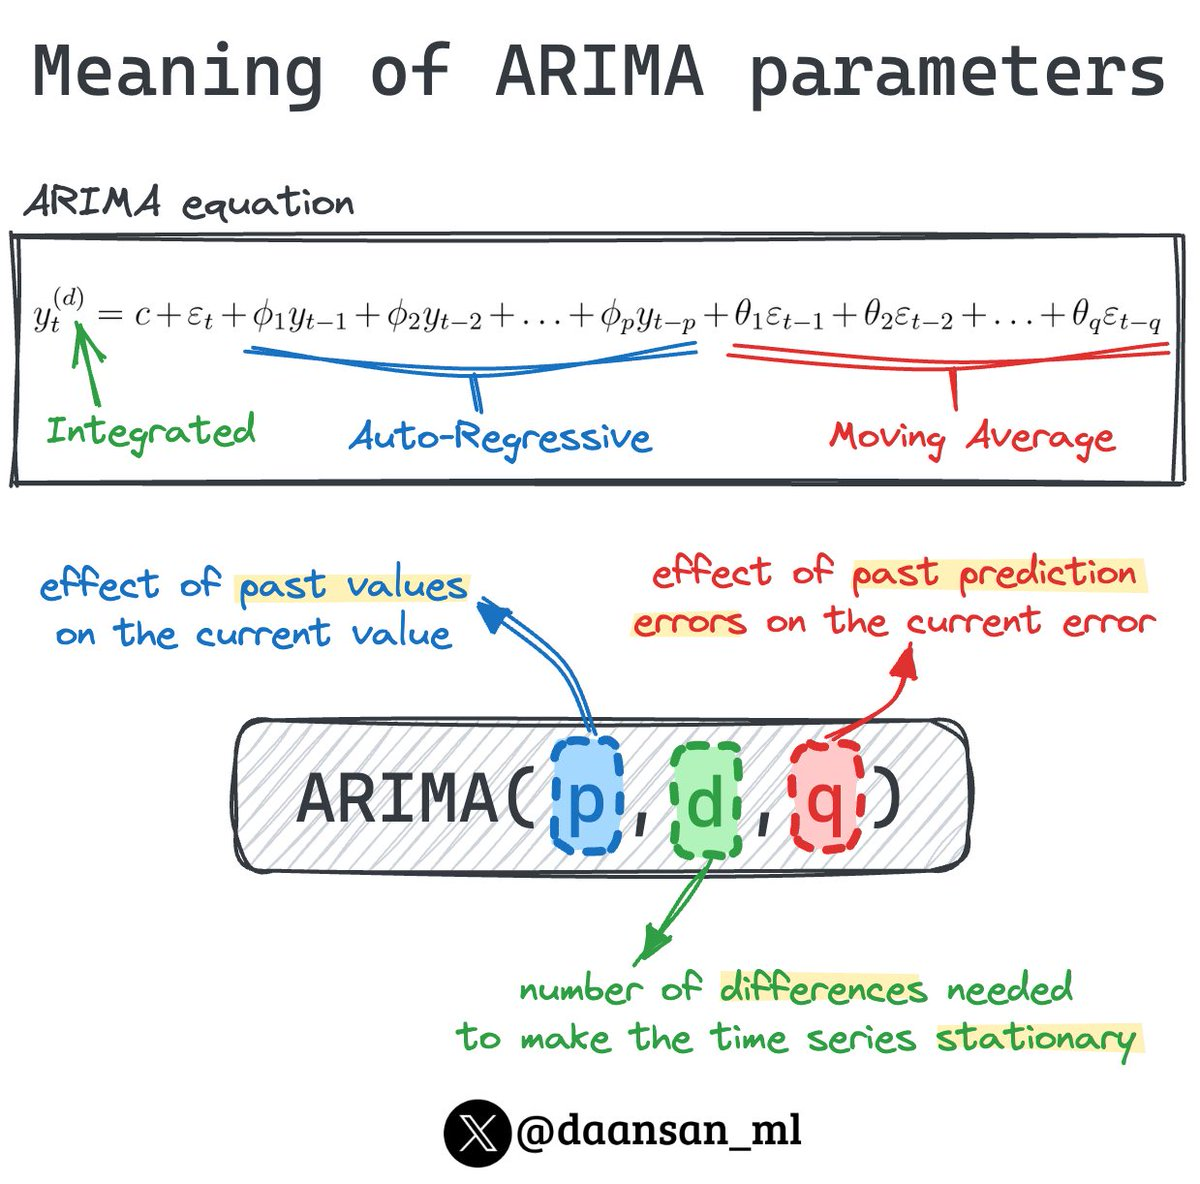

In [59]:
from IPython.display import Image, display
display(Image("./Grid Search ARMA.jpg"))

In [34]:
p_params = range(1,11)
q_params = range(1,5)

In [35]:
# Create dictionary to store MAEs
mae_grid = dict()
# Outer loop: Iterate through possible values for `p`
for p in p_params:
    # Create key-value pair in dict. Key is `p`, value is empty list.
    mae_grid[p] = list()
    # Inner loop: Iterate through possible values for `q`
    for q in q_params:
        # Combination of hyperparameters for model
        order = (p, 0, q)
        # Note start time
        start_time = time.time()
        # Train model
        try:
            model = ARIMA(y_train,order=order).fit(method_kwargs={"maxiter": 500})
        except:
            print(f"Failed to train ARIMA {order}.")
            continue
        # Calculate model training time
        elapsed_time = round(time.time() - start_time, 2)
        print(f"Trained ARIMA {order} in {elapsed_time} seconds.")
        # Generate in-sample (training) predictions
        y_pred = model.predict()
        # Calculate training MAE
        mae = mean_absolute_error(y_train, y_pred)
        # Append MAE to list in dictionary
        mae_grid[p].append(mae)

print()
print(mae_grid)

Trained ARIMA (1, 0, 1) in 0.36 seconds.
Trained ARIMA (1, 0, 2) in 0.52 seconds.
Trained ARIMA (1, 0, 3) in 0.64 seconds.
Trained ARIMA (1, 0, 4) in 0.84 seconds.
Trained ARIMA (2, 0, 1) in 0.5 seconds.
Trained ARIMA (2, 0, 2) in 1.58 seconds.


c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Trained ARIMA (2, 0, 3) in 1.55 seconds.


c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Trained ARIMA (2, 0, 4) in 1.02 seconds.
Trained ARIMA (3, 0, 1) in 0.82 seconds.
Trained ARIMA (3, 0, 2) in 2.68 seconds.


...

Trained ARIMA (7, 0, 3) in 8.71 seconds.


c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Trained ARIMA (7, 0, 4) in 24.14 seconds.
Trained ARIMA (8, 0, 1) in 2.27 seconds.
Trained ARIMA (8, 0, 2) in 14.04 seconds.


c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Trained ARIMA (8, 0, 3) in 16.57 seconds.
Trained ARIMA (8, 0, 4) in 10.38 seconds.
Trained ARIMA (9, 0, 1) in 2.98 seconds.
Trained ARIMA (9, 0, 2) in 2.55 seconds.
Trained ARIMA (9, 0, 3) in 15.67 seconds.
Trained ARIMA (9, 0, 4) in 4.22 seconds.
Trained ARIMA (10, 0, 1) in 1.64 seconds.
Trained ARIMA (10, 0, 2) in 2.83 seconds.
Trained ARIMA (10, 0, 3) in 15.05 seconds.
Trained ARIMA (10, 0, 4) in 31.72 seconds.

{1: [5.5587444048995005, 5.556550544025811, 5.554244614683036, 5.553427866843994], 2: [5.5546586165760745, 5.553476280209437, 5.553146946116464, 5.554073084056037], 3: [5.553327745738946, 5.552997116366679, 5.556124991331865, 5.553548109808641], 4: [5.552889891118182, 5.556583917457801, 5.451339950395942, 5.556187786779475], 5: [5.521704416205, 5.540773132051191, 5.547708099389474, 5.437402109459994], 6: [5.530273133645853, 5.5212979554808985, 5.553227619684547, 5.550730427517682], 7: [5.529707872236961, 5.532257679408035, 5.521262033833007, 5.416267626038762], 8: [5.524363

In [36]:
mae_df = pd.DataFrame(mae_grid)
mae_df.index = q_params
mae_df.round(4)

,1,2,3,4,5,6,7,8,9,10
1,5.5587,5.5547,5.5533,5.5529,5.5217,5.5303,5.5297,5.5244,5.5238,5.5226
2,5.5566,5.5535,5.5530,5.5566,5.5408,5.5213,5.5323,5.3906,5.5244,5.5237
3,5.5542,5.5531,5.5561,5.4513,5.5477,5.5532,5.5213,5.3963,5.5099,5.5258
4,5.5534,5.5541,5.5535,5.5562,5.4374,5.5507,5.4163,5.4209,5.5235,5.5181


In [37]:
y_pred_test = model.predict(y_test.index.min(), y_test.index.max())
test_mae = mean_absolute_error(y_test,y_pred_test)
print("Test MAE:", test_mae)

Test MAE: 11.808104356161403


In [38]:
df_pred_test = pd.DataFrame(
    {"y_test":y_test, "y_pred":y_pred_test}, index= y_test.index
)

In [39]:
fig = px.line(df_pred_test, labels={"value": "P2"})
fig.show()

Text(0.5, 1.0, 'ARMA Grid Search')

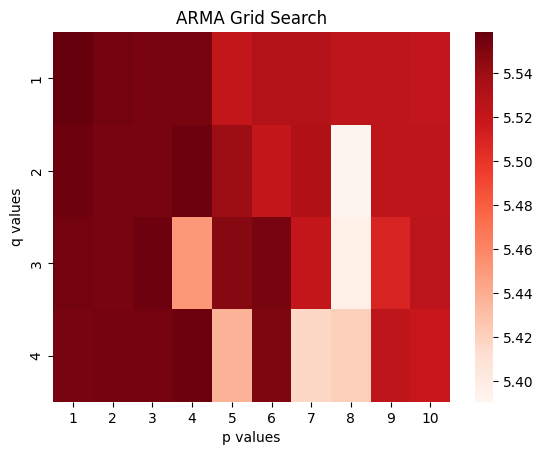

In [40]:
sns.heatmap(mae_df, cmap="Reds")
plt.xlabel("p values")
plt.ylabel("q values")
plt.title("ARMA Grid Search")

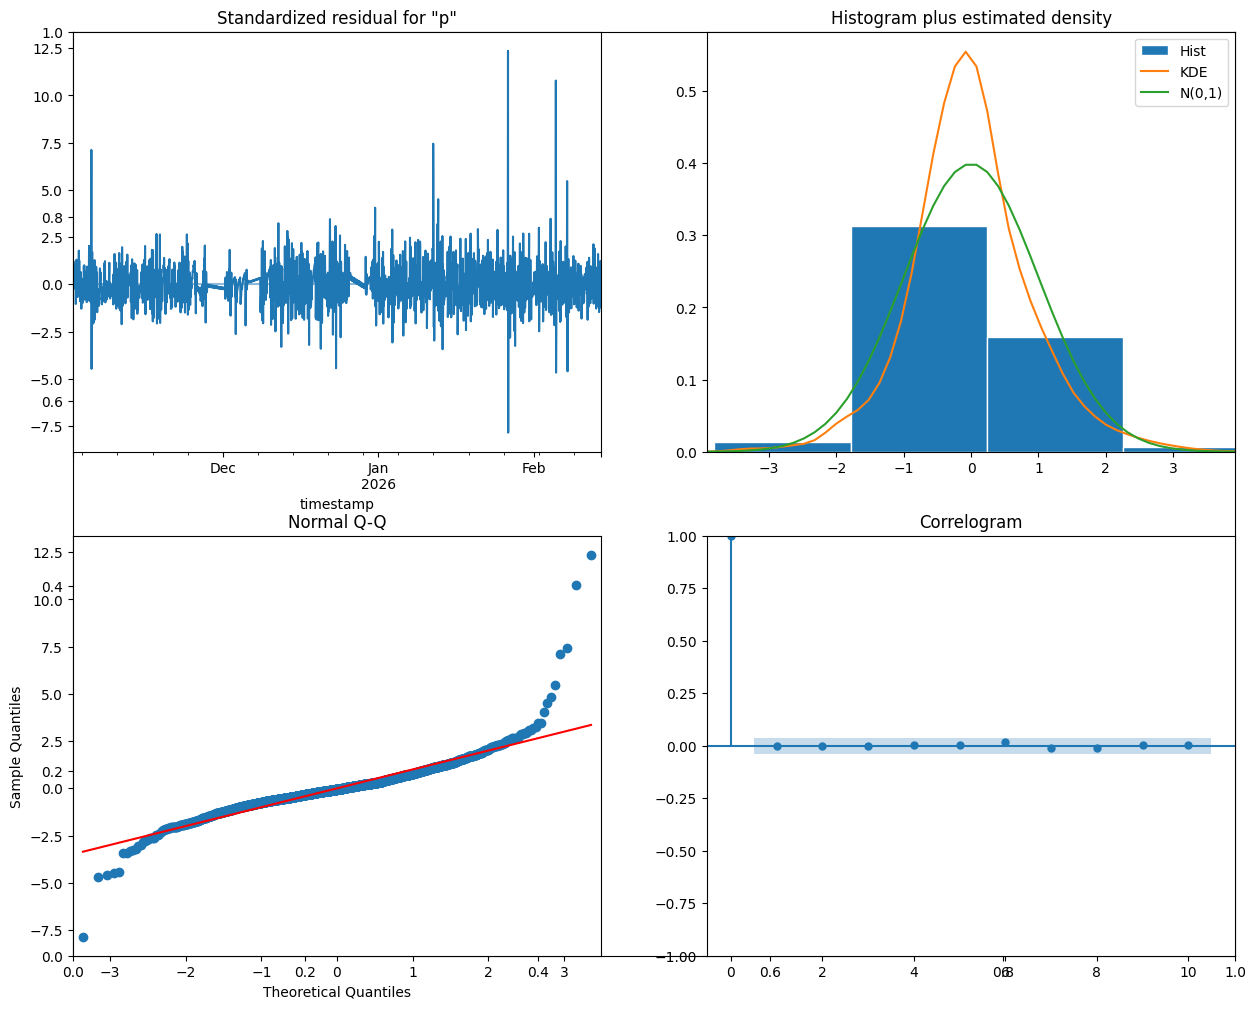

In [41]:
fig, ax = plt.subplots(figsize=(15, 12))
model.plot_diagnostics(fig=fig);

# Walk Forward Validation

In [57]:
def walk_forward_validation(train, test, order, refit_every=5):
    
    history = train.copy()
    predictions = []
    
    model_fit = ARIMA(history, order=order).fit()
    
    for i in range(len(test)):
        #Refit every 5 steps instead of every step
        model_fit = ARIMA(history, order=order).fit(method_kwargs={"maxiter": 1000})
        
        yhat = model_fit.forecast(steps=1)
        predictions.append(yhat.iloc[0])
        
        history = pd.concat([history, test.iloc[i:i+1]])
    
    predictions = pd.Series(predictions, index=test.index)
    mae = mean_absolute_error(test, predictions)
    
    return mae, predictions

In [58]:
order = (2,0,8) 

mae_wfv, y_pred_wfv = walk_forward_validation(y_train, y_test, order)

print("Walk-forward MAE:", round(mae_wfv, 4))

c:\Users\Muhammed\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Walk-forward MAE: 5.2919


In [60]:
df_predictions = pd.DataFrame({
    "y_test":y_test, "y_pred_wfv":y_pred_wfv
})
fig = px.line(df_predictions, labels={"value":"PM2.5"})
fig.show()